# 10 — Under the hood: how the globe frame is built

Digital-Earth draws projected/globe maps **without Cartopy**. Instead of a live per-draw transform, it reprojects the data upstream (pyramids) and assembles a **static projected frame** from pyramids' coordinate transform + numpy. This notebook opens up that machinery in `digitalearth.scene.projections` and plots each step directly with matplotlib (no `Map`, no network):

1. `projection_frame(crs)` — the **boundary** polygon + projected limits.
2. `_convex_hull` — how that boundary is built from sphere samples.
3. `graticule(crs)` — the curved lon/lat grid.
4. `densify_lonlat` — why edges are densified before reprojecting.
5. `_split_finite` — how a **line** crossing the limb is cut into finite runs.
6. `close_visible_runs` — how a **polygon** crossing the limb is re-closed along the boundary (the recipe behind `Map.land()` / `ocean()`).

Everything here is pure geometry — it runs the same online or offline.

## Setup

Imports and a tiny helper to reproject lon/lat to a CRS (off-domain points become inf/nan).

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from digitalearth.scene import projections
from pyramids.base.crs import reproject_coordinates

def reproject(lon, lat, crs):
    """Reproject lon/lat arrays to a CRS as float arrays (off-domain points become inf/nan)."""
    x, y = reproject_coordinates(np.asarray(lon).ravel().tolist(),
                                 np.asarray(lat).ravel().tolist(), from_crs=4326, to_crs=crs)
    return np.asarray(x, float), np.asarray(y, float)

ORTHO = projections.orthographic(lon=0, lat=20)
print('orthographic spec:', ORTHO)

2026-05-31 20:56:37 | INFO | pyramids.base.config | Logging is configured.


orthographic spec: +proj=ortho +lat_0=20 +lon_0=0 +datum=WGS84 +units=m +no_defs


## 1. The projection boundary — `projection_frame`

`projection_frame(crs)` returns `(boundary_xy, (xmin, xmax), (ymin, ymax))`: a closed boundary ring and the projected limits of the CRS's valid domain. The boundary shape tells you the projection family — a **circle** for orthographic, a **rounded rectangle** for Robinson/Mollweide, a **rectangle** for cylindrical.

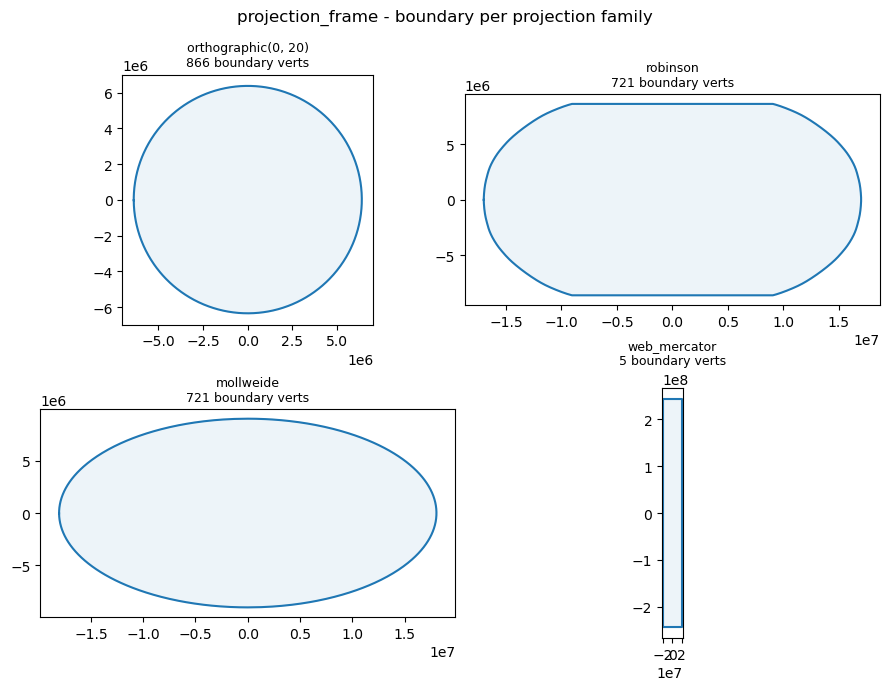

In [2]:
specs = {'orthographic(0, 20)': ORTHO, 'robinson': projections.robinson(),
         'mollweide': projections.mollweide(), 'web_mercator': projections.web_mercator()}
fig, axs = plt.subplots(2, 2, figsize=(9, 7))
for ax, (name, crs) in zip(axs.ravel(), specs.items()):
    ring, xlim, ylim = projections.projection_frame(crs)
    ax.plot(ring[:, 0], ring[:, 1], color='C0')
    ax.fill(ring[:, 0], ring[:, 1], color='C0', alpha=0.08)
    ax.set_title(f'{name}\n{len(ring)} boundary verts', fontsize=9)
    ax.set_aspect('equal'); ax.ticklabel_format(style='sci', scilimits=(0, 0))
fig.suptitle('projection_frame - boundary per projection family')
fig.tight_layout(); fig;

## 2. How the boundary is built — sample the sphere, take the hull

`projection_frame` samples a dense lon/lat grid over the whole sphere, reprojects it, keeps the **finite** points (the near hemisphere, for orthographic), and takes their **convex hull** (`_convex_hull`, Andrew's monotone chain in pure numpy). Below: the finite projected samples (grey) and the hull ring (blue).

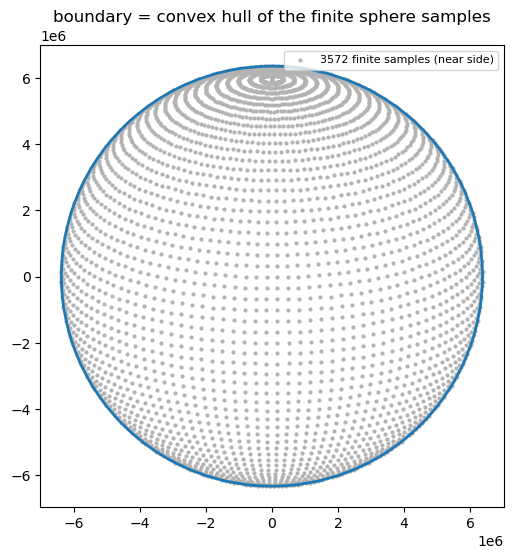

In [3]:
lon = np.linspace(-180, 180, 120)
lat = np.linspace(-90, 90, 60)
glon, glat = np.meshgrid(lon, lat)
px, py = reproject(glon, glat, ORTHO)
mask = np.isfinite(px) & np.isfinite(py)
pts = np.column_stack([px[mask], py[mask]])
hull = projections._convex_hull(pts)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(pts[:, 0], pts[:, 1], s=4, color='0.7', label=f'{len(pts)} finite samples (near side)')
ax.plot(hull[:, 0], hull[:, 1], color='C0', lw=2, label='_convex_hull ring')
ax.set_aspect('equal'); ax.legend(loc='upper right', fontsize=8)
ax.set_title('boundary = convex hull of the finite sphere samples')
fig;

## 3. The graticule — `graticule`

`graticule(crs)` densifies each meridian/parallel, reprojects it, and splits it at non-finite points so the far side never wraps across the figure. The result is the curved lon/lat grid, confined to the boundary.

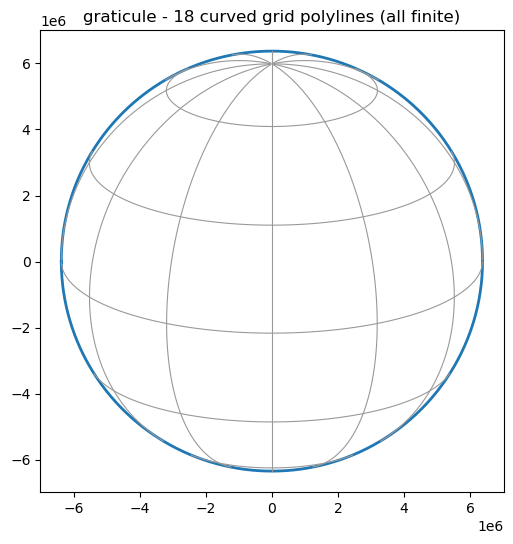

In [4]:
ring, *_ = projections.projection_frame(ORTHO)
lines = projections.graticule(ORTHO, lon_step=30, lat_step=30)
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(ring[:, 0], ring[:, 1], color='C0', lw=2)
for seg in lines:
    ax.plot(seg[:, 0], seg[:, 1], color='0.6', lw=0.8)
ax.set_aspect('equal')
ax.set_title(f'graticule - {len(lines)} curved grid polylines (all finite)')
fig;

## 4. Why densify? — `densify_lonlat`

A straight lon/lat edge curves under projection, and a coarse edge crossing the limb gives a ragged finite/non-finite transition. `densify_lonlat` inserts vertices so each segment is small, making the reprojected curve smooth and the limb crossing sharp. Left: lon/lat; right: projected to the globe.

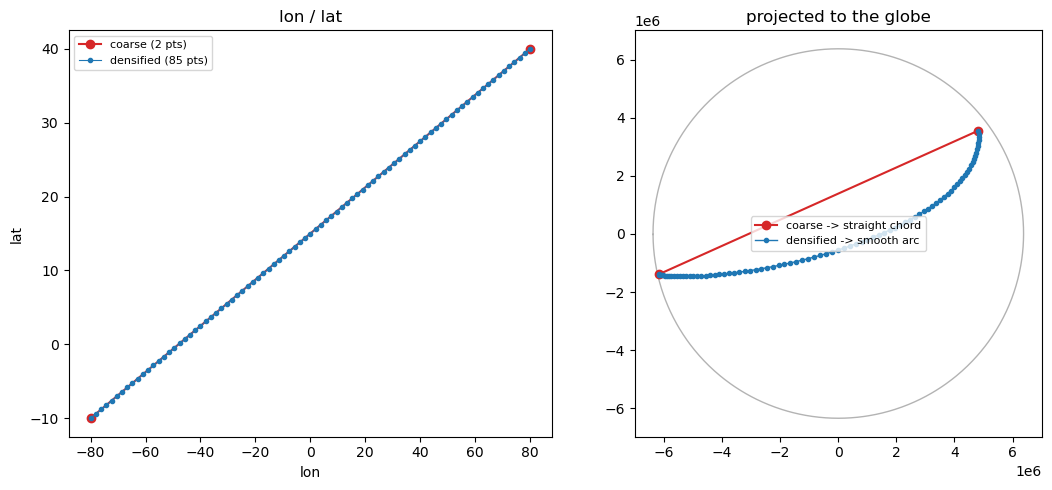

In [5]:
edge = np.array([[-80.0, -10.0], [80.0, 40.0]])   # one long edge that crosses the limb
dense = projections.densify_lonlat(edge, step_deg=2.0)
cx, cy = reproject(edge[:, 0], edge[:, 1], ORTHO)
dx, dy = reproject(dense[:, 0], dense[:, 1], ORTHO)
ring, *_ = projections.projection_frame(ORTHO)

fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 5))
a0.plot(edge[:, 0], edge[:, 1], 'o-', color='C3', label=f'coarse ({len(edge)} pts)')
a0.plot(dense[:, 0], dense[:, 1], '.-', color='C0', lw=0.8, label=f'densified ({len(dense)} pts)')
a0.set_title('lon / lat'); a0.legend(fontsize=8); a0.set_xlabel('lon'); a0.set_ylabel('lat')
a1.plot(ring[:, 0], ring[:, 1], color='0.7', lw=1)
a1.plot(cx, cy, 'o-', color='C3', label='coarse -> straight chord')
a1.plot(dx, dy, '.-', color='C0', lw=1, label='densified -> smooth arc')
a1.set_aspect('equal'); a1.legend(fontsize=8); a1.set_title('projected to the globe')
fig.tight_layout(); fig;

## 5. Cutting a line at the limb — `_split_finite`

Reproject a full parallel (a circle of constant latitude) onto a globe centred at (0, 20): the far half lands at non-finite coordinates. `_split_finite` keeps each contiguous **finite run** as its own polyline — this is what `coastlines()` / `rivers()` use so lines don't wrap across the disc.

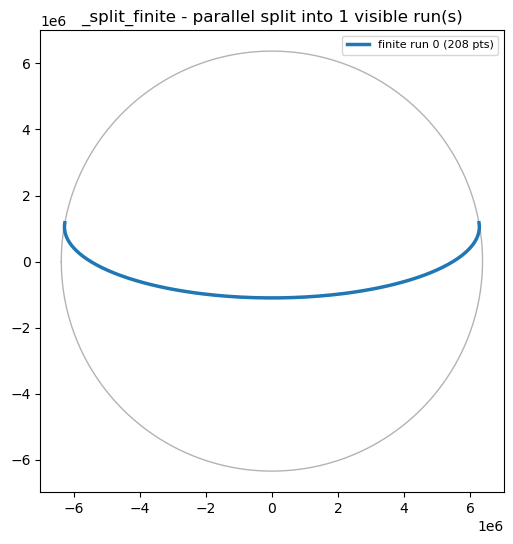

In [6]:
lon = np.linspace(-180, 180, 400)
lat = np.full_like(lon, 10.0)
x, y = reproject(lon, lat, ORTHO)
runs = projections._split_finite(x, y)
ring, *_ = projections.projection_frame(ORTHO)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(ring[:, 0], ring[:, 1], color='0.7', lw=1)
for k, seg in enumerate(runs):
    ax.plot(seg[:, 0], seg[:, 1], lw=2.5, label=f'finite run {k} ({len(seg)} pts)')
ax.set_aspect('equal'); ax.legend(fontsize=8)
ax.set_title(f'_split_finite - parallel split into {len(runs)} visible run(s)')
fig;

## 6. Re-closing a polygon — `close_visible_runs`

For a **fill**, an open finite run is not enough — the visible part must be re-closed into a watertight ring. `close_visible_runs` re-closes each finite run along the **shorter boundary arc** between its endpoints (the limb maps to the boundary). Below, a big lon/lat quad straddles the limb: the dashed grey is the raw reprojected outline (with the far side dropped to gaps); the filled blue rings are the re-closed result.

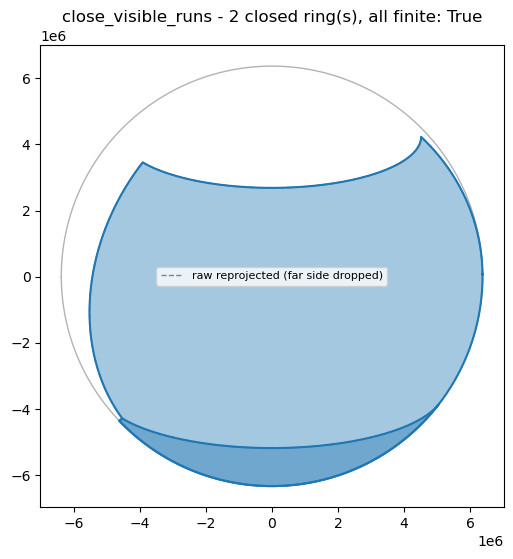

In [7]:
quad_lon = np.r_[np.linspace(-60, 90, 80), np.full(40, 90), np.linspace(90, -60, 80), np.full(40, -60)]
quad_lat = np.r_[np.full(80, -35), np.linspace(-35, 45, 40), np.full(80, 45), np.linspace(45, -35, 40)]
xy = projections.densify_lonlat(np.column_stack([quad_lon, quad_lat]), step_deg=1.0)
x, y = reproject(xy[:, 0], xy[:, 1], ORTHO)
rings = projections.close_visible_runs(x, y, projections.projection_frame(ORTHO)[0])
ring, *_ = projections.projection_frame(ORTHO)

raw_x = np.where(np.isfinite(x), x, np.nan); raw_y = np.where(np.isfinite(y), y, np.nan)
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(ring[:, 0], ring[:, 1], color='0.7', lw=1)
ax.plot(raw_x, raw_y, '--', color='0.5', lw=1, label='raw reprojected (far side dropped)')
for r in rings:
    ax.fill(r[:, 0], r[:, 1], color='C0', alpha=0.4)
    ax.plot(r[:, 0], r[:, 1], color='C0', lw=1.5)
ax.set_aspect('equal'); ax.legend(fontsize=8)
finite = all(np.isfinite(r).all() for r in rings)
ax.set_title(f'close_visible_runs - {len(rings)} closed ring(s), all finite: {finite}')
fig;

## Putting it together

`Map(globe=True)` wires these up: `projection_frame` gives the boundary + limits (memoised in `Map._frame`), `graticule` adds the grid, raster data is reprojected by **pyramids**, and `Map._project_polygon_features` runs `densify_lonlat` -> reproject -> `close_visible_runs` to fill `land()` / `lakes()`, while `_split_finite` feeds the `coastlines()` / `borders()` / `rivers()` lines. **cleopatra**'s `apply_projection_frame` then draws the boundary, clips every layer to it, and turns the axes into the final globe. See notebooks 08 and 09 for the user-facing API.